In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

# Remove unused columns
df = df.drop(df.iloc[:, 2:], axis=1)

# Rename columns
df.columns = ['Labels', 'SMS']

# Encode labels
df['Labels'] = df['Labels'].map({
    'spam': 1,
    'ham': 0
})

X = df['SMS'].values
y = df['Labels'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50
)

In [3]:
bow = CountVectorizer(stop_words='english')

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

mnb_bow = MultinomialNB()

mnb_bow.fit(X_train_bow, y_train)

y_pred_bow = mnb_bow.predict(X_test_bow)

accuracy_bow = accuracy_score(y_test, y_pred_bow)

print(f'CountVectorizer Accuracy: {accuracy_bow:.4f}')

CountVectorizer Accuracy: 0.9830


In [5]:
tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

mnb_tfidf = MultinomialNB()

mnb_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f'TF-IDF Accuracy: {accuracy_tfidf:.4f}')

TF-IDF Accuracy: 0.9605


In [6]:
print('CountVectorizer Accuracy:', accuracy_bow)
print('TF-IDF Accuracy:', accuracy_tfidf)

CountVectorizer Accuracy: 0.9829596412556054
TF-IDF Accuracy: 0.9605381165919282


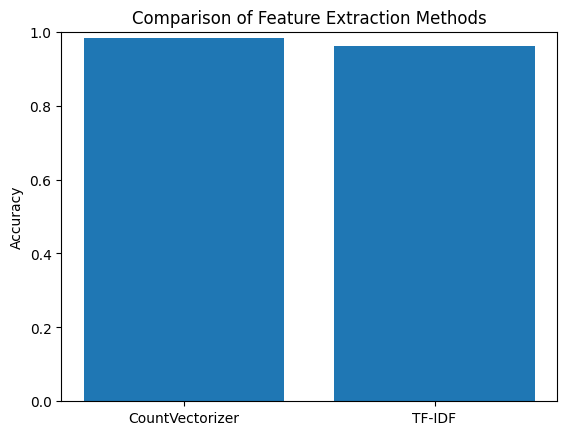

In [7]:
import matplotlib.pyplot as plt

features = ['CountVectorizer', 'TF-IDF']
accuracy = [accuracy_bow, accuracy_tfidf]

plt.bar(features, accuracy)

plt.ylabel('Accuracy')
plt.title('Comparison of Feature Extraction Methods')
plt.ylim(0, 1)

plt.show()

In [8]:
if accuracy_bow > accuracy_tfidf:
    print('CountVectorizer is the optimal feature.')
elif accuracy_tfidf > accuracy_bow:
    print('TF-IDF is the optimal feature.')
else:
    print('Both features have the same accuracy.')

CountVectorizer is the optimal feature.
